# 01 — Exploratory Data Analysis (EDA)
## SkillAlign AI — CV-Job Matching
**Tim:** CC26-PSU318 | **Capstone Project** Coding Camp 2026

---
Notebook ini melakukan analisis eksplorasi terhadap dataset LinkedIn Job Postings
yang akan digunakan untuk melatih model CV-Job Matching.

In [1]:
# ============================================
# 1. IMPORTS & CONFIGURATION
# ============================================
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
print('Setup complete!')

Setup complete!


## 2. Load Dataset

In [2]:
df = pd.read_csv('../Dataset/datasets.csv')
print(f'Dataset shape: {df.shape}')
print(f'Total rows: {df.shape[0]:,}')
print(f'Total columns: {df.shape[1]}')
df.head()

Dataset shape: (581025, 18)
Total rows: 581,025
Total columns: 18


,location,formatted_work_type,applies,remote_allowed,formatted_experience_level,work_type,skill_name,type,max_salary,min_salary,pay_period,currency,industry_name,company_name,state,country,city,speciality
0,"New Hyde Park, NY",Full-time,0.0,0.0,Mid-Senior level,FULL_TIME,Other,401(k),175000.0,140000.0,YEARLY,USD,Law Practice,"Abrams Fensterman, LLP",New York,US,Lake Success,Civil Litigation
1,"New Hyde Park, NY",Full-time,0.0,0.0,Mid-Senior level,FULL_TIME,Other,401(k),175000.0,140000.0,YEARLY,USD,Law Practice,"Abrams Fensterman, LLP",New York,US,Lake Success,Corporate & Securities Law
2,"New Hyde Park, NY",Full-time,0.0,0.0,Mid-Senior level,FULL_TIME,Other,401(k),175000.0,140000.0,YEARLY,USD,Law Practice,"Abrams Fensterman, LLP",New York,US,Lake Success,Criminal Law
3,"New Hyde Park, NY",Full-time,0.0,0.0,Mid-Senior level,FULL_TIME,Other,401(k),175000.0,140000.0,YEARLY,USD,Law Practice,"Abrams Fensterman, LLP",New York,US,Lake Success,Elder Law
4,"New Hyde Park, NY",Full-time,0.0,0.0,Mid-Senior level,FULL_TIME,Other,401(k),175000.0,140000.0,YEARLY,USD,Law Practice,"Abrams Fensterman, LLP",New York,US,Lake Success,Employment Law


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581025 entries, 0 to 581024
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   location                    581025 non-null  object 
 1   formatted_work_type         581025 non-null  object 
 2   applies                     581025 non-null  float64
 3   remote_allowed              581025 non-null  float64
 4   formatted_experience_level  581025 non-null  object 
 5   work_type                   581025 non-null  object 
 6   skill_name                  581025 non-null  object 
 7   type                        581025 non-null  object 
 8   max_salary                  581025 non-null  float64
 9   min_salary                  581025 non-null  float64
 10  pay_period                  581025 non-null  object 
 11  currency                    581025 non-null  object 
 12  industry_name               581025 non-null  object 
 13  company_name  

In [4]:
df.describe()

,applies,remote_allowed,max_salary,min_salary
count,581025.000000,581025.000000,581025.000000,581025.000000
mean,4.060576,0.149766,97538.626724,72279.712627
std,19.946990,0.356843,72926.436961,50821.428440
min,0.000000,0.000000,7.250000,1.000000
25%,0.000000,0.000000,60000.000000,50000.000000
50%,0.000000,0.000000,97525.969351,72272.682146
75%,1.000000,0.000000,132000.000000,100000.000000
max,493.000000,1.000000,1000000.000000,575000.000000


In [5]:
df.describe(include='object')

,location,formatted_work_type,formatted_experience_level,work_type,skill_name,type,pay_period,currency,industry_name,company_name,state,country,city,speciality
count,581025,581025,581025,581025,581025,581025,581025,581025,581025,581025,581025,581025,581025,581025
unique,2178,6,6,6,35,12,4,1,272,3025,210,34,981,17807
top,United States,Full-time,Mid-Senior level,FULL_TIME,Sales,401(k),YEARLY,USD,Staffing and Recruiting,Hemphill - Search • Consulting • Staffing,California,US,New York,Staffing
freq,52369,524536,314146,524536,51974,167376,433880,581025,37237,19734,47279,519010,45874,5612


## 3. Missing Values Analysis

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df.sort_values('Missing %', ascending=False)
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %


In [7]:
if missing_df[missing_df['Missing Count'] > 0].shape[0] > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    mp = missing_df[missing_df['Missing Count'] > 0]
    bars = ax.barh(mp.index, mp['Missing %'], color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', ha='left', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada missing values!')

Tidak ada missing values!


## 4. Distribusi Kolom Kategorikal

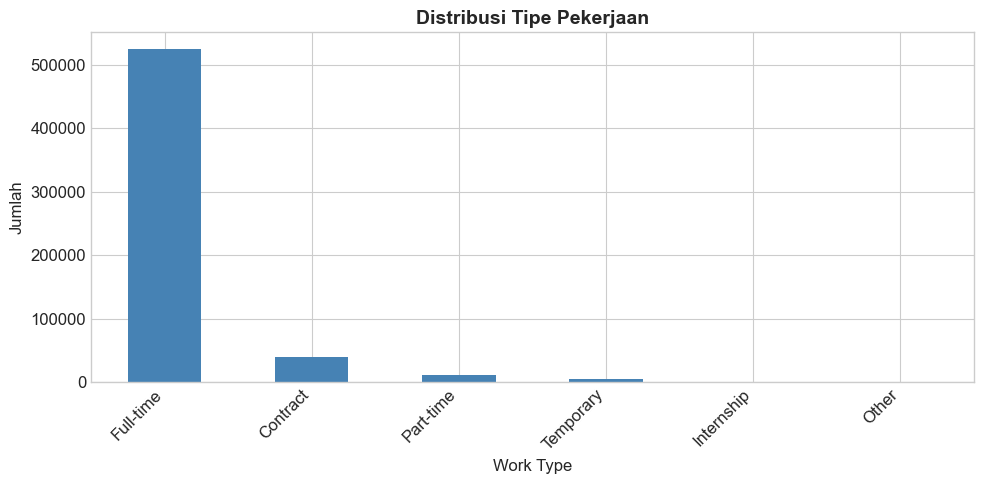

In [8]:
# Distribusi Work Type
if 'formatted_work_type' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    df['formatted_work_type'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Distribusi Tipe Pekerjaan', fontsize=14, fontweight='bold')
    ax.set_xlabel('Work Type')
    ax.set_ylabel('Jumlah')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

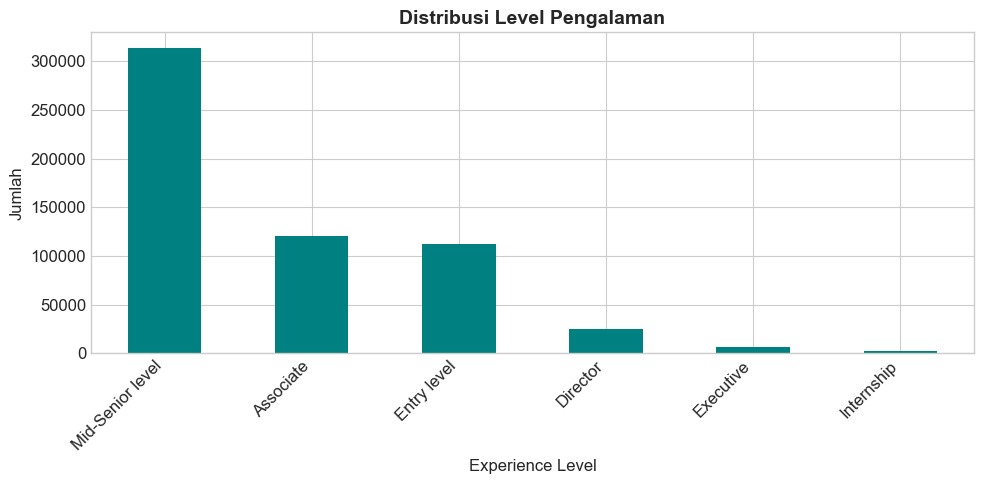

In [9]:
# Distribusi Experience Level
if 'formatted_experience_level' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    df['formatted_experience_level'].value_counts().plot(kind='bar', ax=ax, color='teal')
    ax.set_title('Distribusi Level Pengalaman', fontsize=14, fontweight='bold')
    ax.set_xlabel('Experience Level')
    ax.set_ylabel('Jumlah')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

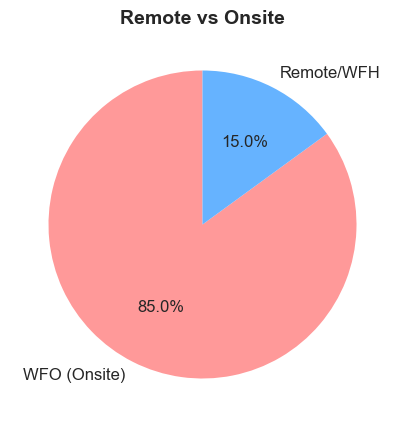

In [10]:
# Distribusi Remote Allowed
if 'remote_allowed' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    remote_counts = df['remote_allowed'].value_counts()
    labels = ['WFO (Onsite)', 'Remote/WFH']
    colors = ['#ff9999', '#66b3ff']
    ax.pie(remote_counts, labels=labels[:len(remote_counts)], autopct='%1.1f%%',
           colors=colors[:len(remote_counts)], startangle=90)
    ax.set_title('Remote vs Onsite', fontsize=14, fontweight='bold')
    plt.show()

## 5. Analisis Skills

Total unique skills: 35


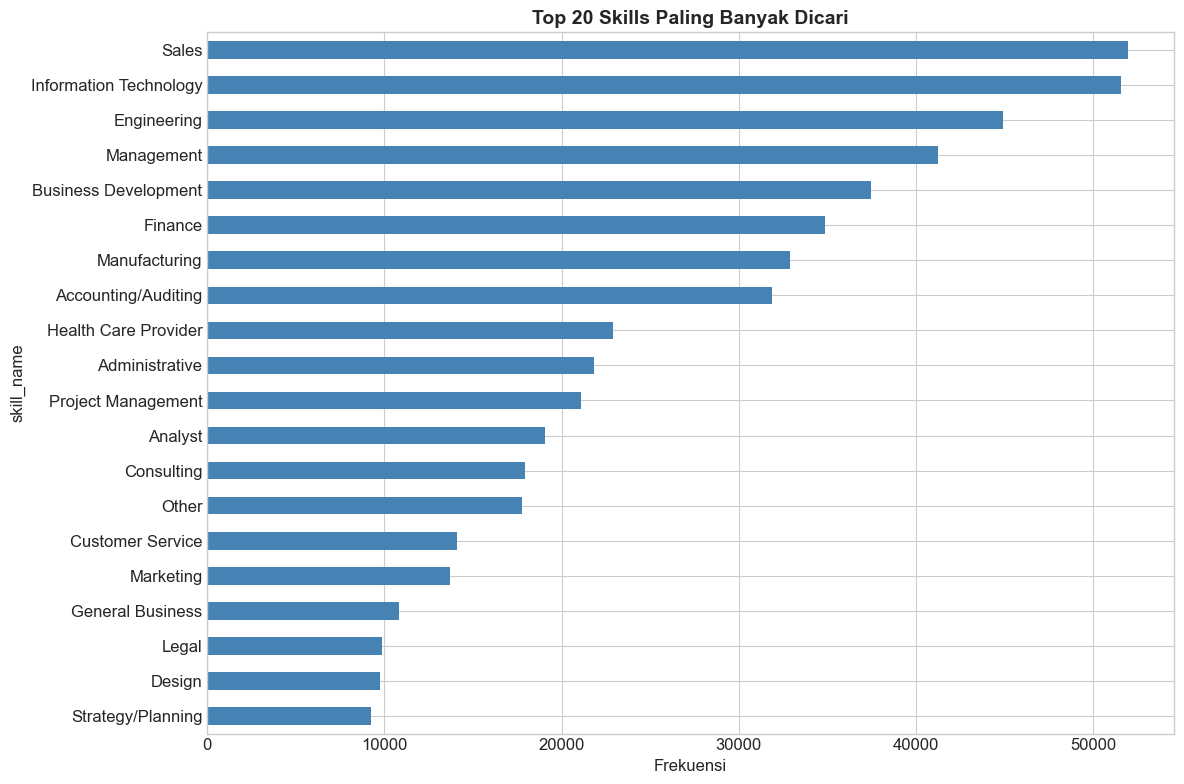

In [11]:
if 'skill_name' in df.columns:
    top_skills = df['skill_name'].value_counts().head(20)
    print(f'Total unique skills: {df["skill_name"].nunique()}')
    fig, ax = plt.subplots(figsize=(12, 8))
    top_skills.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 20 Skills Paling Banyak Dicari', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 6. Analisis Salary

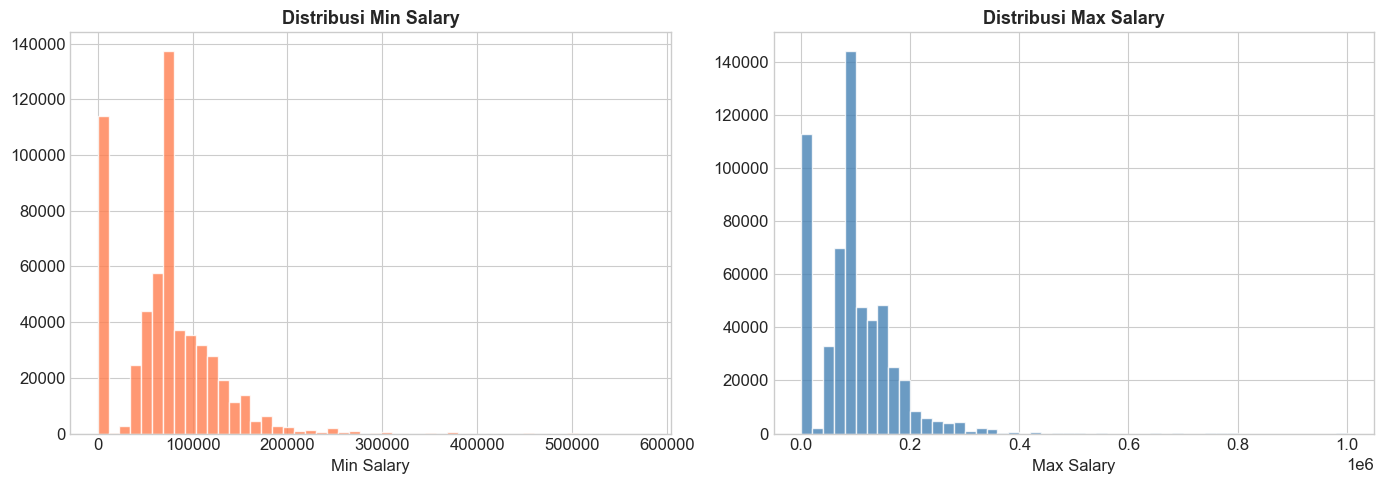


Distribusi Pay Period:
pay_period
YEARLY     433880
HOURLY     143111
MONTHLY      2894
WEEKLY       1140
Name: count, dtype: int64


In [12]:
if 'max_salary' in df.columns and 'min_salary' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df['min_salary'].dropna(), bins=50, color='coral', edgecolor='white', alpha=0.8)
    axes[0].set_title('Distribusi Min Salary', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Min Salary')
    axes[1].hist(df['max_salary'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].set_title('Distribusi Max Salary', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Max Salary')
    plt.tight_layout()
    plt.show()
    if 'pay_period' in df.columns:
        print('\nDistribusi Pay Period:')
        print(df['pay_period'].value_counts())

## 7. Analisis Industry & Location

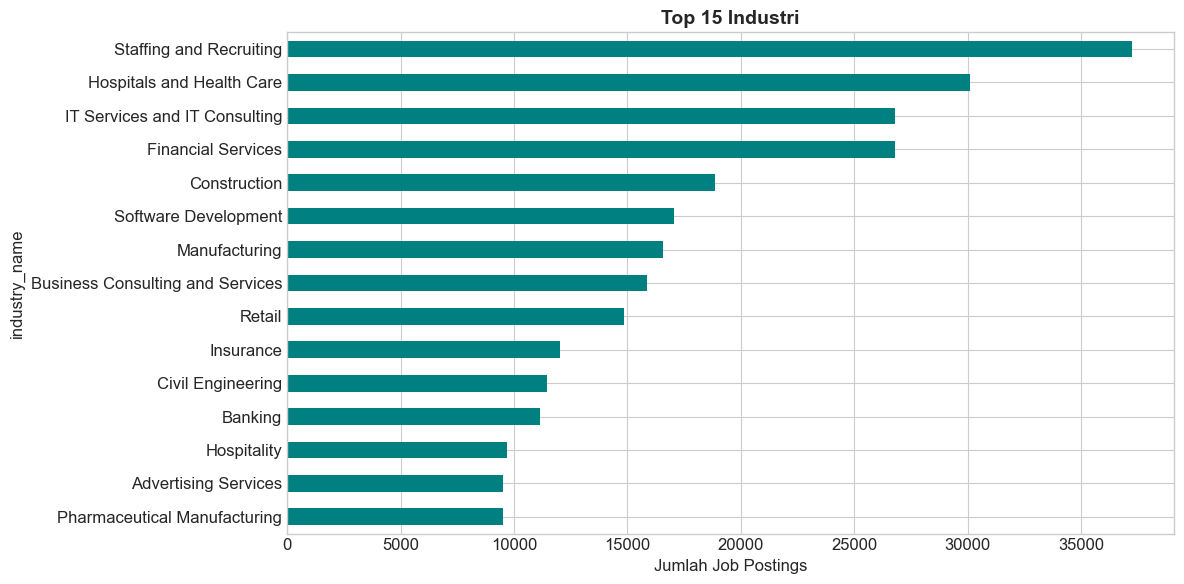

In [13]:
if 'industry_name' in df.columns:
    top_ind = df['industry_name'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 6))
    top_ind.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 15 Industri', fontsize=14, fontweight='bold')
    ax.set_xlabel('Jumlah Job Postings')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

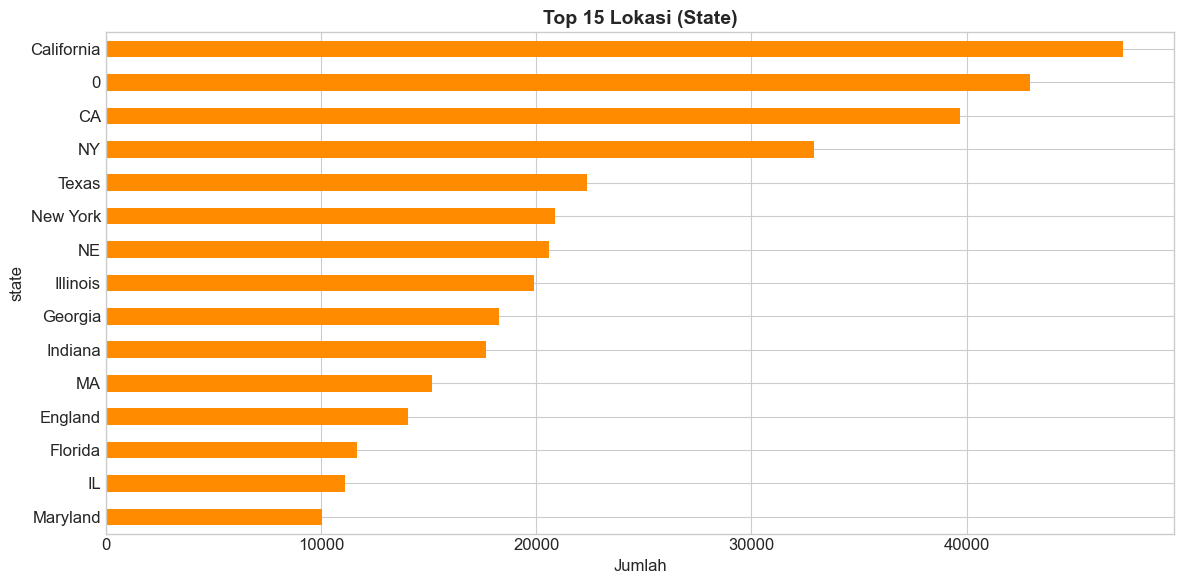

In [14]:
if 'state' in df.columns:
    top_states = df['state'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 6))
    top_states.plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('Top 15 Lokasi (State)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Jumlah')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 8. Analisis Teks dari job_posting.csv

In [15]:
# Load job_posting.csv untuk analisis teks (kolom title, job_description, skills_desc)
try:
    df_posting = pd.read_csv(
        '../Dataset/database_design/job_posting.csv',
        usecols=['job_posting_id', 'title', 'job_description', 'skills_desc'],
        nrows=50000
    )
    print(f'Job Posting sample: {df_posting.shape}')
    print(f'Non-null counts:\n{df_posting.notnull().sum()}')
    df_posting.head(3)
except Exception as e:
    print(f'Error: {e}')
    df_posting = None

Job Posting sample: (50000, 4)
Non-null counts:
job_posting_id     50000
title              50000
job_description    49998
skills_desc          941
dtype: int64


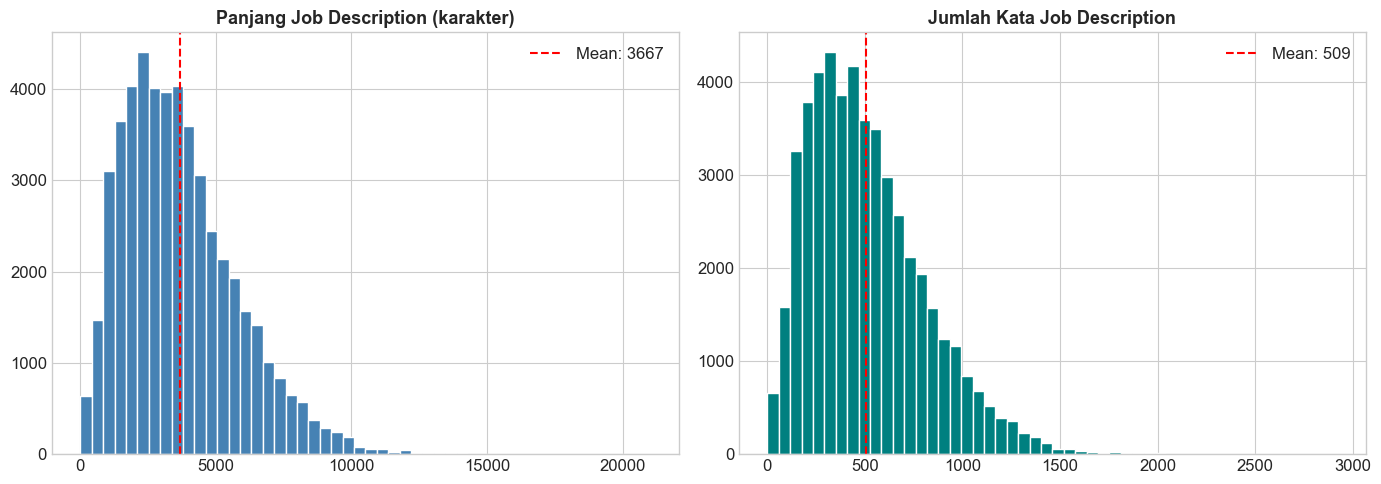

In [16]:
if df_posting is not None and 'job_description' in df_posting.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    desc_len = df_posting['job_description'].dropna().str.len()
    axes[0].hist(desc_len, bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title('Panjang Job Description (karakter)', fontsize=13, fontweight='bold')
    axes[0].axvline(desc_len.mean(), color='red', linestyle='--', label=f'Mean: {desc_len.mean():.0f}')
    axes[0].legend()
    word_count = df_posting['job_description'].dropna().str.split().str.len()
    axes[1].hist(word_count, bins=50, color='teal', edgecolor='white')
    axes[1].set_title('Jumlah Kata Job Description', fontsize=13, fontweight='bold')
    axes[1].axvline(word_count.mean(), color='red', linestyle='--', label=f'Mean: {word_count.mean():.0f}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

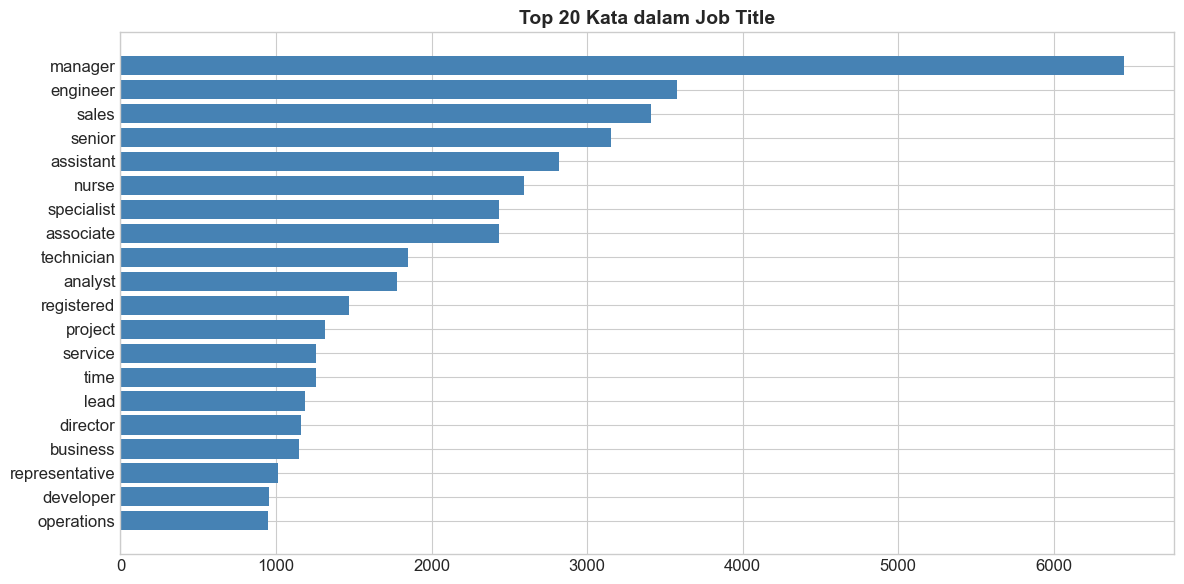

In [17]:
# Top words in Job Titles
if df_posting is not None and 'title' in df_posting.columns:
    all_words = ' '.join(df_posting['title'].dropna()).lower().split()
    stop = {'and','the','of','a','an','in','to','for','is','at','with','-','&','/'}
    words = [w for w in all_words if w not in stop and len(w) > 2]
    top_w = Counter(words).most_common(20)
    fig, ax = plt.subplots(figsize=(12, 6))
    w_list, c_list = zip(*top_w)
    ax.barh(range(len(w_list)), c_list, color='steelblue')
    ax.set_yticks(range(len(w_list)))
    ax.set_yticklabels(w_list)
    ax.set_title('Top 20 Kata dalam Job Title', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 9. Correlation Matrix

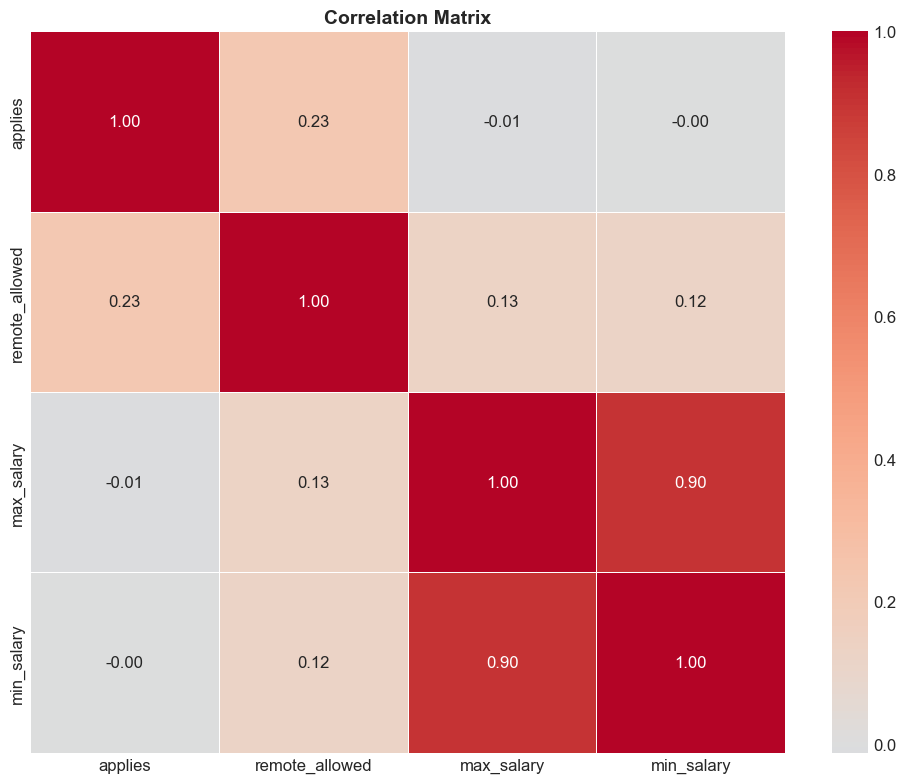

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax, linewidths=0.5)
    ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Kesimpulan EDA

In [19]:
print('=' * 60)
print('DATA QUALITY SUMMARY')
print('=' * 60)
print(f'Total Rows: {len(df):,}')
print(f'Total Columns: {len(df.columns)}')
print(f'Duplicate Rows: {df.duplicated().sum():,}')
print(f'Total Missing Values: {df.isnull().sum().sum():,}')
if 'skill_name' in df.columns:
    print(f'Unique Skills: {df["skill_name"].nunique()}')
if 'industry_name' in df.columns:
    print(f'Unique Industries: {df["industry_name"].nunique()}')
if 'company_name' in df.columns:
    print(f'Unique Companies: {df["company_name"].nunique()}')
print('\nColumn Types:')
print(df.dtypes.value_counts())
print('=' * 60)
print('\nKesimpulan:')
print('- Dataset siap untuk preprocessing')
print('- Perlu generate synthetic CV text + matching labels untuk training')
print('- job_description & skills_desc ada di job_posting.csv untuk NLP')

DATA QUALITY SUMMARY
Total Rows: 581,025
Total Columns: 18
Duplicate Rows: 0
Total Missing Values: 0
Unique Skills: 35
Unique Industries: 272
Unique Companies: 3025

Column Types:
object     14
float64     4
Name: count, dtype: int64

Kesimpulan:
- Dataset siap untuk preprocessing
- Perlu generate synthetic CV text + matching labels untuk training
- job_description & skills_desc ada di job_posting.csv untuk NLP
